<a href="https://colab.research.google.com/github/yeatescp01/INFO_648_Final_Project/blob/main/Jupyter%20Notebook/INFO_648_Final_Project_(South_Atlantic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**INFO 648: Neighborhood Trajectory Prediction with U.S. Census Data**

##Christian Yeates & Angel FrancoMorales


##**Phase 1: Business Understanding**

The U.S. Department of Economic Development needs to predict which neighborhoods in the South Atlantic Region will experience population growth from 2020 to 2030 and identify the main factors driving this growth. Our model will train on data from 2010 to predict changes for 2020 and forecast growth for 2030. Our goal is to forecast growth by state through 2030 to help the agency allocate federal funds based on predicted growth. To achieve this, our model will beat the majority-class baseline by a 0.5 Area Under the (ROC) Curve  (AUC) threshold or higher. The target variable will be a binary label assigned to each census tract: 1 if the tract's population growth_pct > 0 (grew) = gained population; 0 if ≤ 0 (did not grow) = lost/no gain.

##**Phase 2: Data Understanding**

In [ ]:
import pandas as pd
df = pd.read_csv('student_tracts_raw.csv')

###South Atlantic Region

In [ ]:
south_atlantic = [
    'Delaware', 'Maryland', 'District Of Columbia',
    'Virginia', 'West Virginia', 'North Carolina',
    'South Carolina', 'Georgia', 'Florida'
]
df = df[df['STATE'].isin(south_atlantic)]
print(df.shape)

(13706, 49)


In [ ]:
print(df['settlement_type'].value_counts())

settlement_type
suburban    5345
urban       5020
rural       3245
Name: count, dtype: int64


###Population Growth by State

In [ ]:
print(df['STATE'].value_counts())

STATE
Florida                 4245
North Carolina          2195
Georgia                 1969
Virginia                1907
Maryland                1406
South Carolina          1103
West Virginia            484
Delaware                 218
District Of Columbia     179
Name: count, dtype: int64


###Target Variable and Class Balance

In [ ]:
df['growth_pct'] = (df['pop_total_2020'] - df['pop_total_2010']) / df['pop_total_2010'] * 100
df['grew'] = (df['growth_pct'] > 0).astype(int)
print(df['grew'].value_counts())
print()
print(df['grew'].value_counts(normalize=True))

grew
1    9555
0    4151
Name: count, dtype: int64

grew
1    0.69714
0    0.30286
Name: proportion, dtype: float64


Here, we can observe that only 69.7% of South Atlantic tracts gained population from 2010 through 2020. Classes are moderately imbalanced; the majority class baseline accuracy is 70%. AUC is chosen as the primary metric because it is robust to class imbalance.

###EDA Visuals

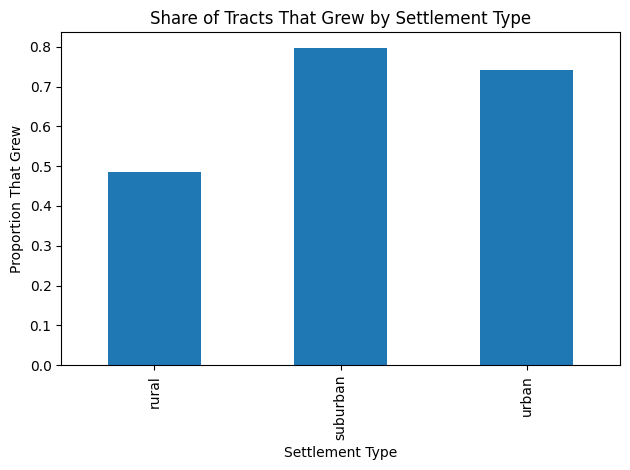

In [ ]:
import matplotlib.pyplot as plt

df.groupby('settlement_type')['grew'].mean().plot(kind='bar')
plt.title('Share of Tracts That Grew by Settlement Type')
plt.ylabel('Proportion That Grew')
plt.xlabel('Settlement Type')
plt.tight_layout()
plt.show()

Suburban tracts grew the most, at 80%, followed by Urban tracts at 75%, and finally rural tracts at only 49%, which means that rural areas were likely to gain or lose population. Suburban and Urban areas clearly dominated in growth from 2010 through 2020.

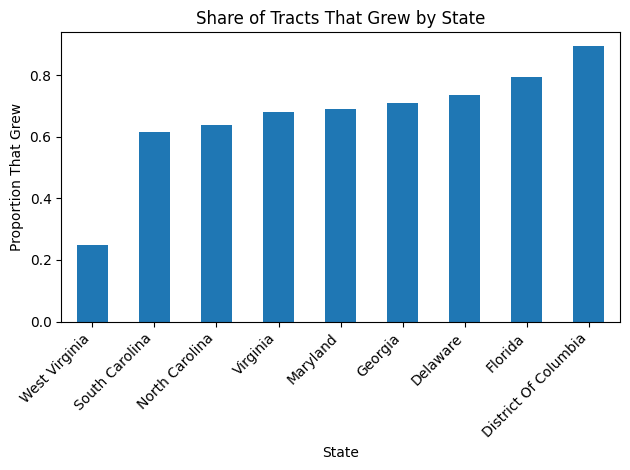

In [ ]:
df.groupby('STATE')['grew'].mean().sort_values().plot(kind='bar')
plt.title('Share of Tracts That Grew by State')
plt.ylabel('Proportion That Grew')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This visual shows that the District of Columbia and Florida had the biggest growth rates. Most of the remaining states cluster around 60-75% growth, with one outlier: West Virginia at only 25% growth.  

###Key Findings:

- Division, states, tracts count is currently at 13,706.

- Class balance: 69.7% grew, while 30.3% did not.

- Suburban and urban tracts grew more than rural tracts.

- The District of Columbia and Florida led in growth, while West Virginia was a clear outlier.

- 148 tracts were missing the settlement type/land area and will be handled in Phase 3.



##**Phase 3: Data Preparation**

###Drop zero-population tracts:

In [ ]:
df = df[df['pop_total_2010'] > 0]
print(df.shape)

(13558, 51)


###Drop water zero-area tracts:

In [ ]:
df = df[df['land_area_sqkm'] > 0]
print(df.shape)

(13558, 51)


###Drop population less than 100:

In [ ]:
df = df[df['pop_total_2010'] >= 100]
print(df.shape)

(13515, 51)


In [ ]:
# Housing rates
df['pct_vacant'] = df['housing_vacant_2010'] / (df['housing_occupied_2010'] + df['housing_vacant_2010'])
df['pct_renter'] = df['housing_renter_occ_2010'] / df['housing_occupied_2010']
df['pct_owner'] = df['housing_owner_occ_2010'] / df['housing_occupied_2010']

# Age rates
df['pct_under18'] = (df['age_under5_2010'] + df['age_5to9_2010'] +
                     df['age_10to14_2010'] + df['age_15to17_2010']) / df['pop_total_2010']
df['pct_65plus'] = (df['age_65to69_2010'] + df['age_70to74_2010'] +
                    df['age_75to79_2010'] + df['age_80to84_2010'] +
                    df['age_85plus_2010']) / df['pop_total_2010']

# Race rates
df['pct_nhwhite'] = df['race_nhwhite_2010'] / df['pop_total_2010']
df['pct_nhblack'] = df['race_nhblack_2010'] / df['pop_total_2010']
df['pct_hispanic'] = (df['race_hispwhite_2010'] + df['race_hispblack_2010'] +
                      df['race_hispother_2010']) / df['pop_total_2010']

print(df[['pct_vacant','pct_renter','pct_owner','pct_under18','pct_65plus','pct_nhwhite','pct_nhblack','pct_hispanic']].describe())

         pct_vacant    pct_renter     pct_owner   pct_under18    pct_65plus  \
count  13503.000000  13500.000000  13500.000000  13515.000000  13515.000000   
mean       0.130023      0.336665      0.663335      0.222146      0.148460   
std        0.105086      0.210496      0.210496      0.064534      0.097727   
min        0.000000      0.015918      0.000000      0.000000      0.000000   
25%        0.067670      0.175980      0.538196      0.193447      0.092085   
50%        0.103679      0.279174      0.720826      0.229734      0.131437   
75%        0.154300      0.461804      0.824020      0.262206      0.174015   
max        1.000000      1.000000      0.984082      0.549030      0.893687   

        pct_nhwhite   pct_nhblack  pct_hispanic  
count  13515.000000  13515.000000  13515.000000  
mean       0.613792      0.221384      0.105348  
std        0.280040      0.248569      0.150449  
min        0.002520      0.000000      0.000000  
25%        0.429699      0.040057     

In [ ]:
df['pct_renter'] = df['pct_renter'].fillna(0)
df['pct_owner'] = df['pct_owner'].fillna(0)
print(df[['pct_renter','pct_owner']].isnull().sum())

pct_renter    0
pct_owner     0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X = df[['pct_vacant', 'pct_renter', 'pct_owner', 'pct_under18', 'pct_65plus',
        'pct_nhwhite', 'pct_nhblack', 'pct_hispanic',
        'density_perkm2', 'settlement_type', 'STATE']]

y = df['grew']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(10812, 11) (2703, 11)


Train/split created before any fitting (80/20, random_state=42). After cleaning the data, we are at 10,812 training tracts and 2,703 test tracts. We conducted the split here to prevent data leakage into our scaling and clustering steps.

##Part 3 Summary:

Rate features were built using per-tract denominators. We cleaned the data by dropping tracts with zero population, zero area, or a population under 100. NaN housing rates were filled with 0, and the target variable was constructed with grew = 1 if growth_pct is greater than 0.

##**Phase 4: Modeling**

###K-Means Clustering for Neighborhood Types

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

numeric_features = ['pct_vacant', 'pct_renter', 'pct_owner', 'pct_under18', 'pct_65plus', 'pct_nhwhite', 'pct_nhblack', 'pct_hispanic', 'density_perkm2']
categorical_features = ['settlement_type', 'STATE']

###Preprocessing Pipeline (Fit on Train, Transform Test)

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [ ]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('cluster', KMeans(n_clusters=4, random_state=42, n_init=20))
])

pipeline.fit(X_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pct_vacant', 'pct_renter',
                                                   'pct_owner', 'pct_under18',
                                                   'pct_65plus', 'pct_nhwhite',
                                                   'pct_nhblack',
                                                   'pct_hispanic',
                                                   'density_perkm2']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['settlement_type',
                                                   'STATE'])])),
                ('cluster', KMeans(n_clusters=4, n_init=20, random_state=42))])

###K-Means - Elbow Method

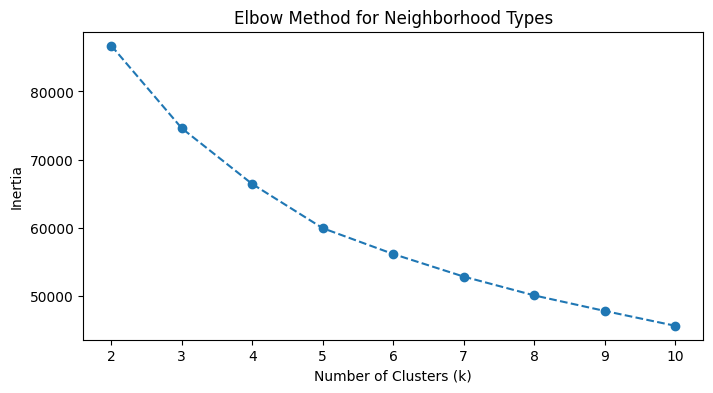

In [ ]:
#Code was AI generated using Gemini
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_preprocessed)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Neighborhood Types')
plt.show()

###Re-fitting K-Means on the correctly preprocessed (imputed) data & Ablation Setup

In [ ]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

In [ ]:
X_train_with_cluster = X_train.copy()
X_test_with_cluster = X_test.copy()

X_train_with_cluster['cluster'] = kmeans.fit_predict(X_train_preprocessed).astype(str)
X_test_with_cluster['cluster'] = kmeans.predict(X_test_preprocessed).astype(str)

In [ ]:
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features + ['cluster'])
    ])

In [ ]:
X_train_plus = preprocessor_final.fit_transform(X_train_with_cluster)
X_test_plus = preprocessor_final.transform(X_test_with_cluster)

print(f"Data preparation complete. Clusters added: {optimal_k}")

Data preparation complete. Clusters added: 5


###Cluster Table

In [ ]:
cluster_summary = X_train_with_cluster.groupby('cluster')[numeric_features].mean()
display(cluster_summary)

,pct_vacant,pct_renter,pct_owner,pct_under18,pct_65plus,pct_nhwhite,pct_nhblack,pct_hispanic,density_perkm2
cluster,,,,,,,,,
0,0.099065,0.221610,0.778390,0.237369,0.140369,0.749549,0.126825,0.065986,520.618853
1,0.109763,0.453501,0.546499,0.236540,0.114596,0.223737,0.126365,0.575663,3514.146855
2,0.135144,0.503871,0.496129,0.263759,0.108869,0.186624,0.688587,0.075966,1565.852512
3,0.121904,0.617463,0.376620,0.168218,0.107069,0.594482,0.203599,0.108696,2172.188729
4,0.355735,0.215809,0.780909,0.119033,0.373999,0.870439,0.042230,0.059570,760.899562


###Cluster Interpretations

- Cluster 0: Affluent, Older, White, Suburban/Exurban
  - Characterized by low vacant and renter percentages, high owner-occupancy, a higher proportion of elderly residents, and a predominantly white population. These areas most likely represent stable communities.
- Cluster 1: Dense, Diverse, Renter-heavy, Urban
  - Characterized by high renter percentages, lower owner-occupancy, high population density, and a population mostly consisting of Blacks and Hispanics. These areas most likely represent vibrant and diverse urban communities.
- Cluster 2: Mixed-Income, Mid-Density Areas
  - Characterized by moderate percentages across vacant, renter, and owner-occupied housing, as well as having a predominantly white population, with a notable Black population. These areas most likely represent mid-density and mixed-income communities.
- Cluster 3: Rural, Aging, White, High Vacancy
  - Characterized by high vacant housing percentages, low renter rates, a very high proportion of elderly residents, a predominantly white population, and very low population density. These areas most likely represent older and more rural communiites.
- Cluster 4: Diverse, Higher Density Transitional Areas
  - Characteristics similar to Cluster 1, but with moderate renter/owner proportions, slightly lower population density, and a predominantly Black and Hispanic population. These areas most likely represent diverse and potentially growing communities.

## **Phase 5: Evaluation**

###Confusion Matrix & ROC Curve

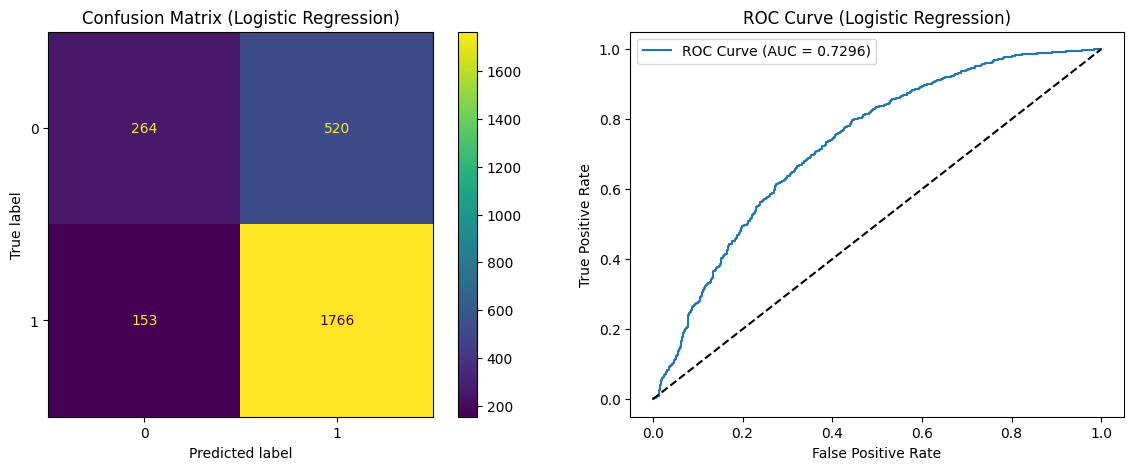

In [ ]:
#Code was AI generated using Gemini
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
import matplotlib.pyplot as plt

# Instantiate and fit the Logistic Regression model with the specified hyperparameters
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_preprocessed, y_train)

# Make predictions and get probabilities for the test set
y_pred_lr = log_reg_model.predict(X_test_preprocessed)
y_probs_lr = log_reg_model.predict_proba(X_test_preprocessed)[:, 1]

# Create subplots for Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm_lr).plot(ax=ax[0])
ax[0].set_title('Confusion Matrix (Logistic Regression)')

# Plot ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
auc_lr = auc(fpr_lr, tpr_lr)
ax[1].plot(fpr_lr, tpr_lr, label=f'ROC Curve (AUC = {auc_lr:.4f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve (Logistic Regression)')
ax[1].legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.63      0.34      0.44       784
           1       0.77      0.92      0.84      1919

    accuracy                           0.75      2703
   macro avg       0.70      0.63      0.64      2703
weighted avg       0.73      0.75      0.72      2703



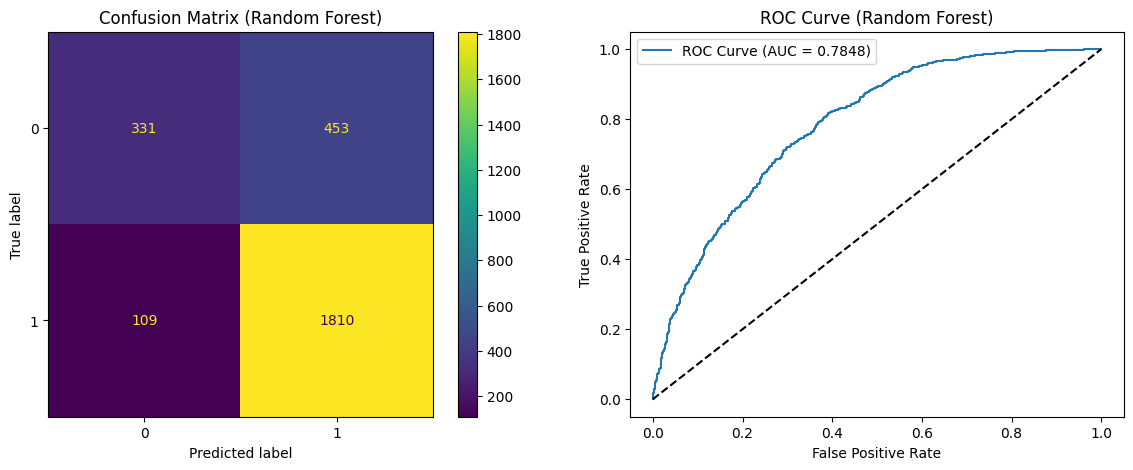

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
best_rf.fit(X_train_preprocessed, y_train)

y_pred = best_rf.predict(X_test_preprocessed)
y_probs = best_rf.predict_proba(X_test_preprocessed)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0])
ax[0].set_title('Confusion Matrix (Random Forest)')

fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.4f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve (Random Forest)')
ax[1].legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.75      0.42      0.54       784
           1       0.80      0.94      0.87      1919

    accuracy                           0.79      2703
   macro avg       0.78      0.68      0.70      2703
weighted avg       0.79      0.79      0.77      2703



###Metric Chosen **(AUC)**

AUC was chosen due to the dataset being imbalanced (~70% neighborhood growth), meaning accuracy can be misleading. While recall is important in identifying growing areas, precision is also just as important in avoiding the waste of federal funds on areas that will not grow. AUC finds an effective middle-ground to balance these tradeoffs.

###Feature Importance

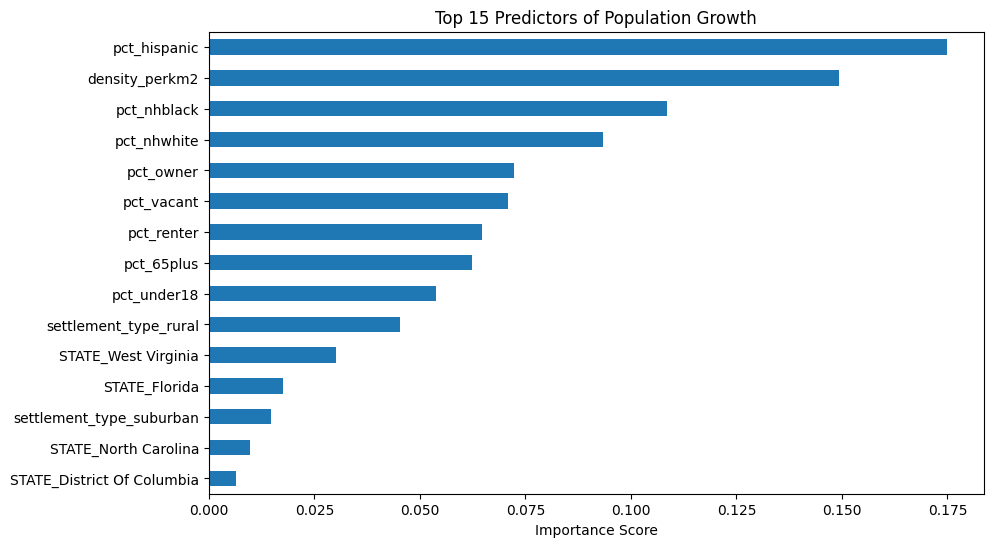

In [ ]:
#Code was AI generated using Gemini
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
all_features = numeric_features + list(cat_encoder.get_feature_names_out(categorical_features))
feat_imp = pd.Series(best_rf.feature_importances_, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh').invert_yaxis()
plt.title('Top 15 Predictors of Population Growth')
plt.xlabel('Importance Score')
plt.show()

Hispanic population percentage `(pct_hispanic)`, population density `(density_perkm2)`, and Black population percentage `(pct_nhblack)` are the top three predictors of population growth. These results suggest that areas with a higher Hispanic population grew significantly more than other demographics in 2010. Moreover, densely populated areas are more likely to continue expanding compared to less densely populated areas.

###Model Comparison & Ablation Study (Logistic Regression and Random Forest)


In [ ]:
#Code was AI generated using Gemini
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
}

results = []

for name, model in models.items():
    # Without Cluster (Using base preprocessed data)
    model.fit(X_train_preprocessed, y_train)
    auc_no = roc_auc_score(y_test, model.predict_proba(X_test_preprocessed)[:, 1])

    # With Cluster (Using 'plus' preprocessed data)
    model.fit(X_train_plus, y_train)
    auc_with = roc_auc_score(y_test, model.predict_proba(X_test_plus)[:, 1])

    results.append({
        'Model': name,
        'AUC (No Cluster)': round(auc_no, 4),
        'AUC (With Cluster)': round(auc_with, 4),
        'Improvement': round(auc_with - auc_no, 4)
    })

display(pd.DataFrame(results))

,Model,AUC (No Cluster),AUC (With Cluster),Improvement
0,Logistic Regression,0.7296,0.7283,-0.0013
1,Random Forest,0.7848,0.7824,-0.0024


###Interpretation
Adding clusters slightly decreased the AUC for both the Random Forest and Logistic Regression model. This indicates that both models are already capable of capturing the underlying demographic patterns, meaning that clustering did not help either model.

As for leakage, the train-test split was performed before any scaling or clustering. Additionally, the K-means was fit only on the training set and then applied to the test set.

The Phase 1 success criterion was to beat the majority-class baseline (AUC) of 0.5 by at least 0.15. With a final AUC of **0.7848**, the model was a success.

The Random Forest model is the best since it has the highest AUC score **(0.7848)**.

## **Phase 6: Deployment (Forecasting 2020-2030)**

###South Atlantic Region

In [ ]:
fc = pd.read_csv('forecast_tracts_2020.csv')
south_atlantic = ['Delaware', 'Maryland', 'District Of Columbia', 'Virginia', 'West Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida']
fc = fc[fc['STATE'].isin(south_atlantic)]

In [ ]:
#The rest of the code in this phase was AI generated using Gemini
# 1. Clean and Normalize (Same logic as Phase 3)
fc = fc[fc['pop_total_2020'] >= 100]

# Housing, Age, and Race rates for 2020
fc['pct_vacant'] = fc['housing_vacant_2020'] / (fc['housing_occupied_2020'] + fc['housing_vacant_2020'])
fc['pct_renter'] = fc['housing_renter_occ_2020'] / fc['housing_occupied_2020']
fc['pct_owner'] = fc['housing_owner_occ_2020'] / fc['housing_occupied_2020']
fc['pct_under18'] = (fc['age_under5_2020'] + fc['age_5to9_2020'] + fc['age_10to14_2020'] + fc['age_15to17_2020']) / fc['pop_total_2020']
fc['pct_65plus'] = (fc['age_65to69_2020'] + fc['age_70to74_2020'] + fc['age_75to79_2020'] + fc['age_80to84_2020'] + fc['age_85plus_2020']) / fc['pop_total_2020']
fc['pct_nhwhite'] = fc['race_nhwhite_2020'] / fc['pop_total_2020']
fc['pct_nhblack'] = fc['race_nhblack_2020'] / fc['pop_total_2020']
fc['pct_hispanic'] = (fc['race_hispwhite_2020'] + fc['race_hispblack_2020'] + fc['race_hispother_2020']) / fc['pop_total_2020']

fc[['pct_renter', 'pct_owner']] = fc[['pct_renter', 'pct_owner']].fillna(0)

In [ ]:
# 2. Forecast Growth using the Frozen Model
X_fc = fc[numeric_features + categorical_features]
X_fc_preprocessed = preprocessor.transform(X_fc)
fc['predicted_growth'] = best_rf.predict(X_fc_preprocessed)

In [ ]:
# 3. Summarize Findings by State
state_forecast = fc.groupby('STATE')['predicted_growth'].mean().sort_values(ascending=False).to_frame()
state_forecast.columns = ['Proportion of Tracts Predicted to Grow']
display(state_forecast)

,Proportion of Tracts Predicted to Grow
STATE,
Delaware,0.995327
District Of Columbia,0.988827
Florida,0.955561
Maryland,0.903458
North Carolina,0.833641
Virginia,0.826226
Georgia,0.778119
South Carolina,0.737179
West Virginia,0.198347


###Forecasting Assumptions (2020-2030)
The demographic drivers of growth observed between 2010 and 2020 will remain the primary drivers in the next decade. Major disruptions, such as shifts in remote work or extreme climate events, could alter these trajectories.

###Recommendation to the Department of Economic Development

Florida, Delaware, and Washington DC show the most predicted growth in the South Atlantic region. The key factors driving these results are population density, as well as both Hispanic and Black population percentage in these areas.

This model is useful for useful in indetifying potentially growing neighborhoods, allowing the Department of Economic Development to allocate resources more efficiently than allocating specifically by state. However, this model lacks economic policy data, which could influence growth that this model would not take into consideration.

One risk when utilizing this model is that states such as West Virginia, where population growth is low, may lead to less investment, leading to further population loss that this model would not predict.